In [50]:
import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import yaml
import os
import logging
from contextlib import nullcontext
import matplotlib.pyplot as plt
import lightgbm as lgb
from catboost import CatBoostRegressor
import xgboost as xgb
from sklearn.linear_model import LinearRegression

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

mlflow_tracking_uri = 'http://127.0.0.1:5000/'  

In [51]:
# Load dataset
train_df = pd.read_csv('../data/processed/train_final.csv')
test_df = pd.read_csv('../data/processed/test_final.csv')

In [52]:
# Kiểm tra lại số cột còn lại
print("Số cột còn lại trong train_df:", train_df.shape[1])
print("Số cột còn lại trong test_df:", test_df.shape[1]) 

Số cột còn lại trong train_df: 17
Số cột còn lại trong test_df: 17


In [53]:
# Split train_df into training and validation sets based on Year and WeekOfYear
val_condition = (train_df['Year'] == 2015) & (train_df['WeekOfYear'] >= 26)

train_set = train_df[~val_condition].copy()
val_set = train_df[val_condition].copy()

In [54]:
# Time-based split: Use last 6 months of 2015 as validation set
val_condition = (train_df['Year'] == 2015) & (train_df['WeekOfYear'] >= 26)

train_set = train_df[~val_condition].copy()
val_set = train_df[val_condition].copy()

# More Feature engineering

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

# 1. OOF ENCODING CHO TRAIN_SET 

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Tạo cột rỗng
train_set['Store_DW_Promo_Avg'] = np.nan
train_set['Month_Avg_Sales'] = np.nan

for train_idx, val_idx in kf.split(train_set):
    fold_train = train_set.iloc[train_idx]
    fold_val = train_set.iloc[val_idx]

    # --- Store_DW_Promo_Avg ---
    store_dw_promo_avg = fold_train.groupby(['Store', 'DayOfWeek', 'Promo'])['Sales_log'].mean()
    
    train_set.loc[train_set.index[val_idx], 'Store_DW_Promo_Avg'] = (
        fold_val.set_index(['Store', 'DayOfWeek', 'Promo']).index.map(store_dw_promo_avg)
    )

    # --- Month_Avg_Sales ---
    month_avg = fold_train.groupby('Month')['Sales_log'].mean()
    
    train_set.loc[train_set.index[val_idx], 'Month_Avg_Sales'] = (
        fold_val['Month'].map(month_avg)
    )

# 2. TÍNH TRÊN FULL TRAIN_SET (CHO VAL & TEST)

store_dw_promo_avg = train_set.groupby(['Store', 'DayOfWeek', 'Promo'])['Sales_log'].mean().reset_index()
store_dw_promo_avg.rename(columns={'Sales_log': 'Store_DW_Promo_Avg'}, inplace=True)

month_avg = train_set.groupby('Month')['Sales_log'].mean().reset_index()
month_avg.rename(columns={'Sales_log': 'Month_Avg_Sales'}, inplace=True)

# 3. MERGE SANG VAL & TEST

val_set = val_set.merge(store_dw_promo_avg, on=['Store', 'DayOfWeek', 'Promo'], how='left')
val_set = val_set.merge(month_avg, on='Month', how='left')

test_df = test_df.merge(store_dw_promo_avg, on=['Store', 'DayOfWeek', 'Promo'], how='left')
test_df = test_df.merge(month_avg, on='Month', how='left')

# 4. FILL NaN

global_mean_train = train_set['Sales_log'].mean()

train_set['Store_DW_Promo_Avg'] = train_set['Store_DW_Promo_Avg'].fillna(global_mean_train)
train_set['Month_Avg_Sales'] = train_set['Month_Avg_Sales'].fillna(global_mean_train)

val_set['Store_DW_Promo_Avg'] = val_set['Store_DW_Promo_Avg'].fillna(global_mean_train)
val_set['Month_Avg_Sales'] = val_set['Month_Avg_Sales'].fillna(global_mean_train)

test_df['Store_DW_Promo_Avg'] = test_df['Store_DW_Promo_Avg'].fillna(global_mean_train)
test_df['Month_Avg_Sales'] = test_df['Month_Avg_Sales'].fillna(global_mean_train)

# 5. ĐỒNG BỘ FEATURE

feature_cols = [c for c in train_set.columns if c not in ['Sales', 'Sales_log']]

val_set = val_set[feature_cols + ['Sales_log']]
test_df_features = test_df[feature_cols]

Đã xử lý xong train_set, val_set và test_df!
Feature mới đã nạp: ['Store_DW_Promo_Avg', 'Month_Avg_Sales']


In [56]:
# drop Promo2 ở 3 tập
train_set = train_set.drop(columns=['Promo2',], errors='ignore')
val_set = val_set.drop(columns=['Promo2'], errors='ignore')
test_df = test_df.drop(columns=['Promo2'], errors='ignore')

In [57]:
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805202 entries, 0 to 805201
Data columns (total 18 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Store                    805202 non-null  int64  
 1   DayOfWeek                805202 non-null  int64  
 2   Promo                    805202 non-null  int64  
 3   StateHoliday             805202 non-null  int64  
 4   SchoolHoliday            805202 non-null  int64  
 5   StoreType                805202 non-null  int64  
 6   Assortment               805202 non-null  int64  
 7   CompetitionDistance_log  805202 non-null  float64
 8   Sales_log                805202 non-null  float64
 9   Year                     805202 non-null  int64  
 10  Month                    805202 non-null  int64  
 11  Day                      805202 non-null  int64  
 12  WeekOfYear               805202 non-null  int64  
 13  Promo2Open_Month         805202 non-null  float64
 14  Comp

In [58]:
# Danh sách các biến cần loại bỏ khỏi đầu vào của mô hình
drop_cols = ['Sales', 'Sales_log', 'Customers','Month']

X_train = train_set.drop(columns=drop_cols, errors='ignore')
y_train = train_set['Sales_log']

X_val = val_set.drop(columns=drop_cols, errors='ignore')
y_val = val_set['Sales_log']

<Axes: >

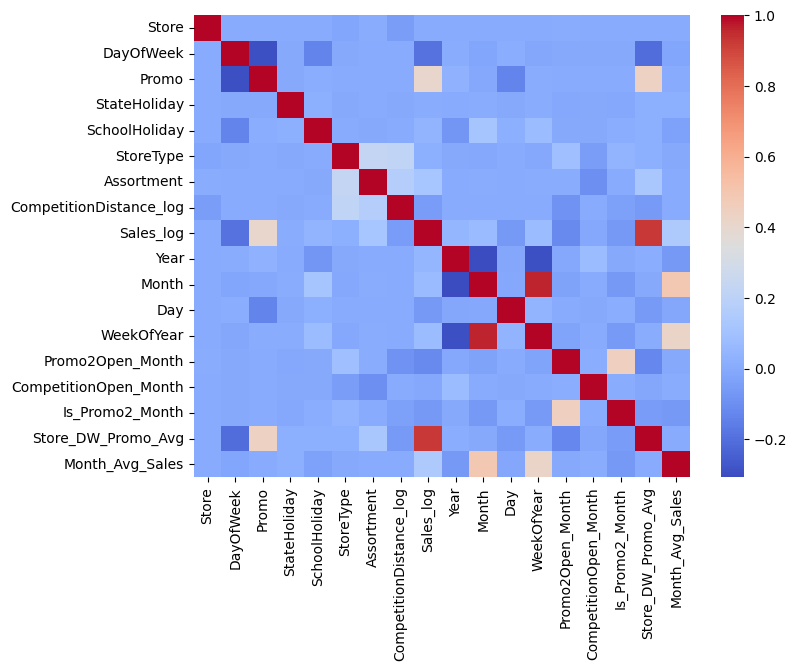

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(train_set.corr(), cmap='coolwarm')

In [ ]:
# Thêm vào sau phần Feature Engineering của bạn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Định nghĩa các model muốn thử nghiệm
models = {
    'BaselineLR': LinearRegression(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist', random_state=42)
    ,
    'LightGBM': lgb.LGBMRegressor(objective='regression', random_state=42, verbose=-1),
    'CatBoost': CatBoostRegressor(loss_function='RMSE', logging_level='Silent', random_state=42, allow_writing_files=False)
}

# Định nghĩa lưới tham số (Grid) để GridSearchCV tìm kiếm
model_grids = {
    'BaselineLR': {},
    'XGBoost': {
        'learning_rate': [0.02484904299575523],
        'max_depth': [11],
        'subsample': [0.8437880308889292],
        'colsample_bytree': [0.7688520150734801],
        'min_child_weight': [14],
        'gamma': [0.00023429788475798095],
        'n_estimators': [1000]
    }
    ,
    'LightGBM': {
        'n_estimators': [500, 1000],
        'learning_rate': [0.05, 0.1],
        'num_leaves': [31, 64],
        'feature_fraction': [0.8, 0.9]
    },
    'CatBoost': {
        'iterations': [500],
        'learning_rate': [0.05, 0.1],
        'depth': [6, 10],
        'l2_leaf_reg': [1, 3, 5]
    }
}

In [61]:
# Tạo hàm để tính RMSPE
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true)**2))

In [62]:
from sklearn.model_selection import GridSearchCV
import numpy as np

def evaluate_model_rossmann(name, model, grid, X_train, y_train, X_val, y_val):
    # 1. Huấn luyện mô hình
    if grid:
        # Sử dụng GridSearchCV để tìm tham số tốt nhất
        clf = GridSearchCV(model, grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        best_params = clf.best_params_
    else:
        best_model = model
        best_model.fit(X_train, y_train)
        best_params = best_model.get_params()

    # 2. Dự đoán cho cả tập Train và Val (đưa ngược về dạng exp)
    y_train_pred = np.exp(best_model.predict(X_train))
    y_val_pred = np.exp(best_model.predict(X_val))
    
    y_train_true = np.exp(y_train)
    y_val_true = np.exp(y_val)

    # 3. Tính toán RMSPE và Gap (Giống cell cũ của bạn)
    train_rmspe = rmspe(y_train_true, y_train_pred)
    val_rmspe = rmspe(y_val_true, y_val_pred)
    rmspe_gap = val_rmspe - train_rmspe
    
    # In kết quả nhanh để theo dõi
    print(f"[{name}] Train: {train_rmspe:.4f} | Val: {val_rmspe:.4f} | Gap: {rmspe_gap:.4f}")
    
    # 4. Trả về kết quả đầy đủ
    return {
        'train_rmspe': train_rmspe,
        'val_rmspe': val_rmspe,
        'rmspe_gap': rmspe_gap,
        'model': best_model,
        'params': best_params
    }

In [63]:
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Thiết lập MLflow
mlflow.set_tracking_uri("http://127.0.0.1:5000/")
mlflow.set_experiment("Rossmann_Sales_Forecasting")

results = {}

with mlflow.start_run(run_name="Model_Comparison_Suite"):
    for name, model in models.items():
        print(f"Đang thực hiện thí nghiệm cho: {name}...")
        
        with mlflow.start_run(run_name=name, nested=True):
            # --- BƯỚC 1: CHẠY ĐÁNH GIÁ ---
            evaluation = evaluate_model_rossmann(name, model, model_grids[name], X_train, y_train, X_val, y_val)
            results[name] = evaluation
            best_model = evaluation['model']

            # --- BƯỚC 2: LOG METRICS & PARAMS ---
            mlflow.log_params(evaluation['params'])
            mlflow.log_metric("train_rmspe", evaluation['train_rmspe']) 
            mlflow.log_metric("val_rmspe", evaluation['val_rmspe'])
            mlflow.log_metric("rmspe_gap", evaluation['rmspe_gap'])

            # --- BƯỚC 3: DỰ ĐOÁN ĐỂ VẼ RESIDUAL PLOT ---
            y_val_pred_log = best_model.predict(X_val)
            y_val_pred = np.exp(y_val_pred_log)
            y_val_orig = np.exp(y_val)
            residuals = y_val_orig - y_val_pred

            # --- BƯỚC 4: FEATURE IMPORTANCE ---
            plt.figure(figsize=(10, 8))
            try:
                if 'XGBoost' in name:
                    import xgboost as xgb
                    xgb.plot_importance(best_model, max_num_features=15, importance_type='gain', ax=plt.gca())
                elif 'LightGBM' in name:
                    import lightgbm as lgb
                    lgb.plot_importance(best_model, max_num_features=15, importance_type='gain', ax=plt.gca())
                elif 'CatBoost' in name:
                    feat_imp = pd.Series(best_model.get_feature_importance(), index=X_train.columns).sort_values(ascending=False).head(15)
                    feat_imp.plot(kind='barh', ax=plt.gca())
                else: 
                    coefs = pd.Series(np.abs(best_model.coef_), index=X_train.columns).sort_values(ascending=False).head(15)
                    coefs.plot(kind='barh', ax=plt.gca())
                
                plt.title(f"Top 15 Features - {name}")
                plt.tight_layout()
                
                # SỬA ĐỔI: Log Figure trực tiếp, không save file local
                mlflow.log_figure(plt.gcf(), f"feat_imp_{name}.png")
                
            except Exception as e:
                print(f"Không thể vẽ Feature Importance cho {name}: {e}")
            plt.close()

            # --- BƯỚC 5: RESIDUAL ANALYSIS ---
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
            
            # Scatter Plot
            sns.scatterplot(x=y_val_pred, y=residuals, ax=ax1, alpha=0.3)
            ax1.axhline(y=0, color='r', linestyle='--')
            ax1.set_title(f"Predicted vs Residuals - {name}")
            
            # Histogram
            sns.histplot(residuals, kde=True, ax=ax2)
            ax2.set_title(f"Residuals Distribution - {name}")
            
            plt.tight_layout()
            
            # SỬA ĐỔI: Log đối tượng 'fig' trực tiếp lên MLflow
            mlflow.log_figure(fig, f"residuals_{name}.png")
            
            plt.close(fig)

            # --- BƯỚC 6: LƯU MODEL ---
            mlflow.sklearn.log_model(best_model, artifact_path=name.lower().replace(" ", "_"))
            
            print(f"{name} hoàn tất. Val RMSPE: {evaluation['val_rmspe']:.4f}")

print("\nTất cả thí nghiệm đã hoàn thành! Bạn hãy kiểm tra MLflow UI để xem biểu đồ chi tiết.")

Đang thực hiện thí nghiệm cho: BaselineLR...
[BaselineLR] Train: 0.2164 | Val: 0.1573 | Gap: -0.0591


2026/04/17 14:44:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 14:44:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


BaselineLR hoàn tất. Val RMSPE: 0.1573
🏃 View run BaselineLR at: http://127.0.0.1:5000/#/experiments/1/runs/9a4f5090cd2b4297aeedb8be95a2dd68
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
Đang thực hiện thí nghiệm cho: XGBoost...
[XGBoost] Train: 0.1185 | Val: 0.1200 | Gap: 0.0015


2026/04/17 14:57:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 14:57:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost hoàn tất. Val RMSPE: 0.1200
🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/1/runs/2c23a200241e42d5bf4aa01e46c70c14
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
🏃 View run Model_Comparison_Suite at: http://127.0.0.1:5000/#/experiments/1/runs/d0641a5a3d664753a76f64c263b687ad
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

Tất cả thí nghiệm đã hoàn thành! Bạn hãy kiểm tra MLflow UI để xem biểu đồ chi tiết.


In [64]:
import yaml
import os
import joblib

# 1. Tìm model tốt nhất (RMSPE thấp nhất) từ từ điển results
best_model_name = min(results, key=lambda x: results[x]['val_rmspe'])
best_info = results[best_model_name]
best_model_obj = best_info['model']  # Đây là đối tượng model thực tế

# 2. Định nghĩa đường dẫn lưu file (Theo cấu trúc folder của project)
model_folder = '../artifacts/models/'
os.makedirs(model_folder, exist_ok=True)
model_path = os.path.join(model_folder, 'rossmann_model.joblib')

# 3. Tiến hành lưu model bằng joblib
joblib.dump(best_model_obj, model_path)
print(f"Đã xuất file model tại: {model_path}")

# 4. Lưu config (Giữ nguyên phần code cũ của bạn)
model_config = {
    'project': 'Rossmann Store Sales',
    'best_model': {
        'name': best_model_name,
        'rmspe': float(best_info['val_rmspe']),
        'params': best_info['params']
    },
    'features': {
        'input_columns': list(X_train.columns),
        'target': 'Sales_log'
    }
}

config_path = '../configs/model_config.yaml'
os.makedirs(os.path.dirname(config_path), exist_ok=True)

with open(config_path, 'w') as f:
    yaml.dump(model_config, f, default_flow_style=False)

print(f"Đã lưu cấu hình model tốt nhất tại: {config_path}")

Đã xuất file model tại: ../artifacts/models/rossmann_model.joblib
Đã lưu cấu hình model tốt nhất tại: ../configs/model_config.yaml
